# 4.0 Model training - LightGBM


## Imports


In [1]:
import numpy as np
import pandas as pd
import joblib
import json
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.features import GOLDEN_WEEK_FLG
from recruit_restaurant_visitor_forecasting.modeling.train import (
    build_feature_drop_list,
    load_data,
    prepare_features,
    lgbm_gridsearch,
    shap_fs,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred, plot_feature_importances
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred, convert_to_serializable, get_format
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-01-21 00:48:20.361 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
CV_SPLITS = 5
TEST_SIZE = 0.2
USELESS_FEATURES = [
    *[
        VISITORS_NBR_COL + suffix
        for suffix in ["_mean_7", "_mean_14", "_median_7", "_median_28"]
    ],
    GOLDEN_WEEK_FLG,
]
DROP_COLUMNS = [
    AIR_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    VISITORS_NBR_COL,
    DAY_OF_WEEK_COL,
    CITY_COL,
    *USELESS_FEATURES,
]

FS_TOP_K = 35
FS_VALID_SIZE = 0.2

MODEL_NAME = "lightgbm_shap_35"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [4]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Training


### Iteration 1

In [9]:
base_params = {
    "model__max_depth": [4, 5],
    "model__learning_rate": np.logspace(-2, -1, 3),
    "model__n_estimators": [175, 200],
    "model__min_child_samples": [15, 20],
}
params = {
    "model__learning_rate": np.logspace(-2, -0.7, 5),
    "model__n_estimators": [150, 175, 200],
    "model__min_child_samples": [15, 20],
    "model__reg_alpha": [0.0, 0.1, 1.0],
    "model__reg_lambda": [0.0, 0.1, 1.0],
}
param_grid = [
    {
        **params,
        "model__max_depth": [4],
        "model__num_leaves": [11, 15],
    },
    {
        **params,
        "model__max_depth": [5],
        "model__num_leaves": [25, 28, 31],
    },
]

In [10]:
grid_search = lgbm_gridsearch(
    param_grid=base_params,
    verbose=3,
    n_jobs=4,
    drop_features=DROP_COLUMNS,
    n_splits=CV_SPLITS,
)
grid_search.fit(X_train, y_train)
best_idx = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)
print(f"Best score: {grid_search.cv_results_["mean_test_score"][best_idx]:.5f}")
print(f"CV std: {grid_search.cv_results_["std_test_score"][best_idx]:.5f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'model__learning_rate': np.float64(0.1), 'model__max_depth': 5, 'model__min_child_samples': 15, 'model__n_estimators': 200}
Best score: -0.70119
CV std: 0.07118


In [11]:
pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__learning_rate,param_model__max_depth,param_model__min_child_samples,param_model__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
21,4.596684,0.191665,0.009084,0.000938,0.1,5,15,200,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.769880,-0.712226,-0.620860,-0.617707,-0.785275,-0.701189,0.071179,1
20,4.304291,0.056509,0.009193,0.001174,0.1,5,15,175,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.773619,-0.713765,-0.623178,-0.619014,-0.790937,-0.704103,0.072464,2
23,4.258402,0.751744,0.007759,0.000810,0.1,5,20,200,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.771909,-0.708846,-0.628424,-0.622149,-0.799481,-0.706162,0.072305,3
22,4.412340,0.228804,0.008358,0.000719,0.1,5,20,175,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.774650,-0.709340,-0.629914,-0.624268,-0.802020,-0.708038,0.072653,4
17,4.738559,0.315691,0.008717,0.001014,0.1,4,15,200,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.780619,-0.711475,-0.630914,-0.620194,-0.807529,-0.710146,0.075922,5


### SHAP feature selection

In [12]:
model = grid_search.best_estimator_
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
    top_k=FS_TOP_K,
)

In [13]:
FEATURES_TO_DROP = build_feature_drop_list(
    X.columns.tolist(),
    selected_features,
)
FEATURES_TO_KEEP = [c for c in X.columns if c not in FEATURES_TO_DROP]

print("Selected features: ", sorted(selected_features))

Selected features:  ['days_from_holiday', 'holiday_flg', 'nbr_res_visitors_diff', 'nbr_res_visitors_diff_mean_14', 'nbr_res_visitors_diff_mean_28', 'nbr_res_visitors_diff_mean_7', 'open_usually', 'opened_recently', 'res_visitors_diff', 'res_visitors_diff_mean_14', 'res_visitors_diff_mean_28', 'res_visitors_diff_mean_7', 'total_reserves', 'total_reserves_nbrs', 'visitors_dow_mean', 'visitors_dow_mean_nbrs', 'visitors_lag_1', 'visitors_lag_28', 'visitors_lag_7', 'visitors_last_month', 'visitors_max_14', 'visitors_max_7', 'visitors_mean_14', 'visitors_mean_28', 'visitors_mean_7', 'visitors_median_14', 'visitors_median_28', 'visitors_median_7', 'visitors_min_7', 'visitors_nbrs_lag_1', 'visitors_nbrs_lag_28', 'visitors_nbrs_mean_28', 'visitors_nbrs_median_14', 'visitors_nbrs_std_28', 'visitors_std_7']


### Iteration 2

In [16]:
grid_search = lgbm_gridsearch(
    param_grid=param_grid,
    verbose=3,
    n_jobs=6,
    drop_features=FEATURES_TO_DROP,
    n_splits=CV_SPLITS,
)
grid_search.fit(X_train, y_train)
best_idx = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)
print(f"Best score: {grid_search.cv_results_["mean_test_score"][best_idx]:.5f}")
print(f"CV std: {grid_search.cv_results_["std_test_score"][best_idx]:.5f}")

Fitting 5 folds for each of 1350 candidates, totalling 6750 fits
Best parameters: {'model__learning_rate': np.float64(0.19952623149688797), 'model__max_depth': 4, 'model__min_child_samples': 15, 'model__n_estimators': 175, 'model__num_leaves': 15, 'model__reg_alpha': 1.0, 'model__reg_lambda': 0.1}
Best score: -0.70827
CV std: 0.07755


In [17]:
pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__learning_rate,param_model__max_depth,param_model__min_child_samples,param_model__n_estimators,param_model__num_leaves,param_model__reg_alpha,param_model__reg_lambda,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
466,3.942386,0.442337,0.005826,0.000726,0.199526,4,15,175,15,1.0,0.1,"{'model__learning_rate': 0.19952623149688797, ...",-0.770973,-0.720817,-0.621965,-0.617710,-0.809909,-0.708275,0.077549,1
452,3.722491,0.298886,0.005465,0.000532,0.199526,4,15,175,11,0.0,1.0,"{'model__learning_rate': 0.19952623149688797, ...",-0.769740,-0.702867,-0.637209,-0.631979,-0.801585,-0.708676,0.068388,2
434,3.276793,0.072844,0.005874,0.000711,0.199526,4,15,150,11,0.0,1.0,"{'model__learning_rate': 0.19952623149688797, ...",-0.772280,-0.707425,-0.629330,-0.633876,-0.800632,-0.708709,0.069848,3
470,4.106651,0.298457,0.008898,0.006318,0.199526,4,15,200,11,0.0,1.0,"{'model__learning_rate': 0.19952623149688797, ...",-0.768221,-0.700756,-0.642146,-0.632497,-0.802812,-0.709287,0.067376,4
437,3.320699,0.311151,0.006686,0.002107,0.199526,4,15,150,11,0.1,1.0,"{'model__learning_rate': 0.19952623149688797, ...",-0.775212,-0.707426,-0.629326,-0.633877,-0.800999,-0.709368,0.070485,5


### Scores

In [18]:
model_shap = grid_search.best_estimator_

In [19]:
y_train_pred = model_shap.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

Train set metrics:
RMSLE: 0.8383
MAE:  6.6239
R2:   0.6434


In [20]:
y_test_pred, temp_features = recursive_predict(
    model_shap,
    X_test,
    X_train,
    y_train,
    drop_cols=FEATURES_TO_DROP,
)

Predicting recursively: 100%|██████████| 90/90 [24:44<00:00, 16.49s/it]


In [21]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSLE: 0.8147
MAE:  7.1267
R2:   0.5473


## Graphs

### Feature importances

<Figure size 1200x1000 with 0 Axes>

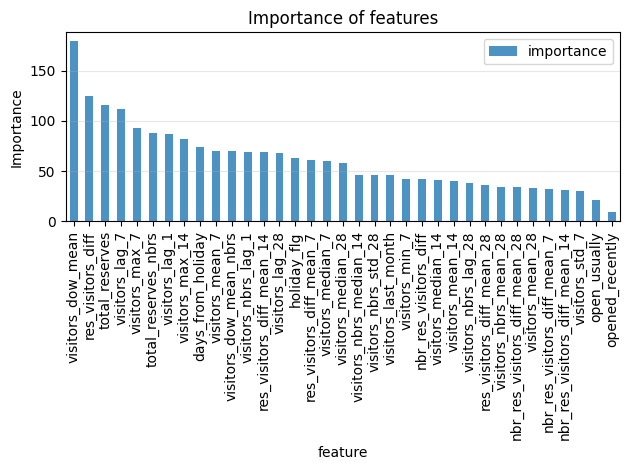

In [22]:
plot_feature_importances(model_shap, FEATURES_TO_KEEP)

## SHAP explanation

In [23]:
X_test_clean = model_shap.named_steps["feature_dropper"].transform(X_test)
lgbm = model_shap.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

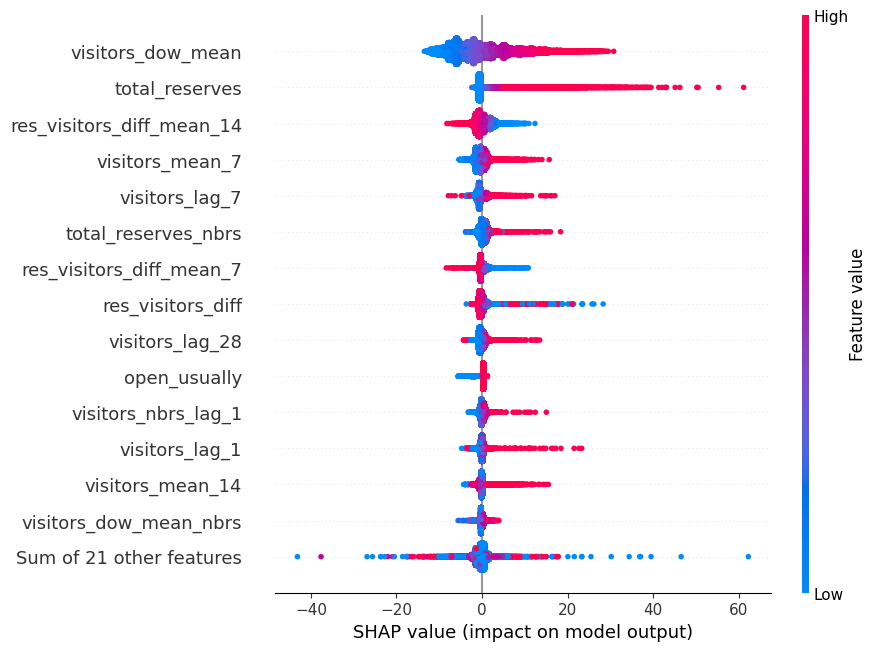

In [24]:
shap.plots.beeswarm(shap_values, max_display=15)

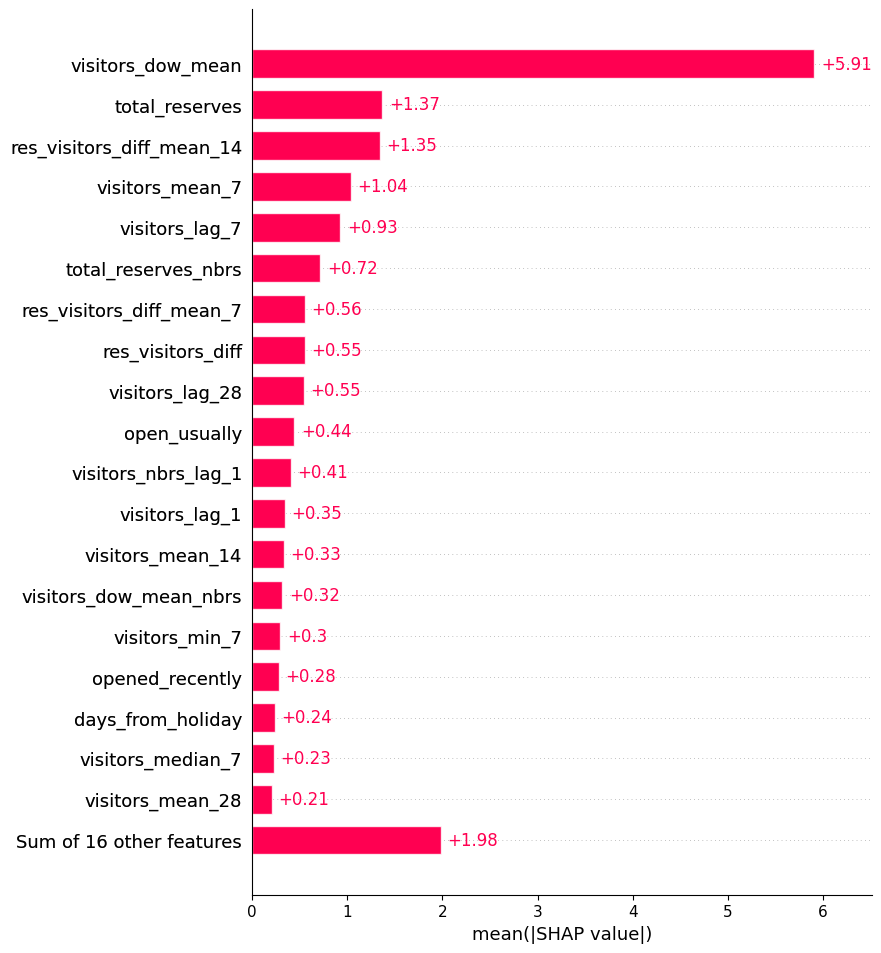

In [25]:
shap.plots.bar(shap_values, max_display=20)

### Visitors per day: actual vs predicted

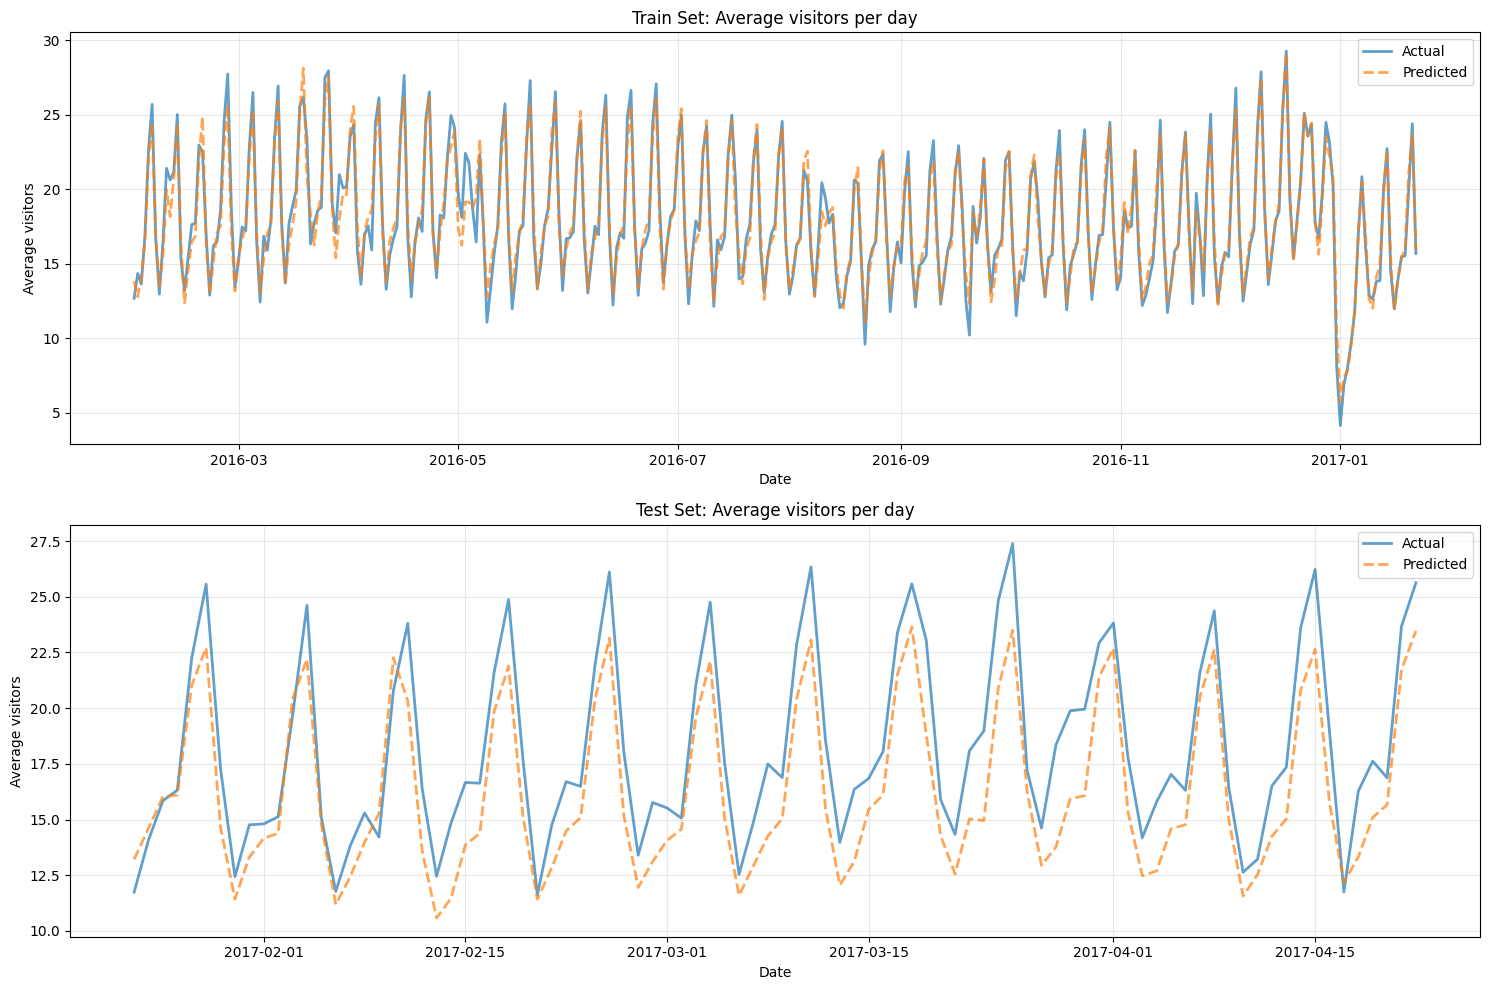

In [26]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [40]:
model = joblib.load(MODEL_PATH)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[9.26234526e-01 3.82807950e-01 9.98857364e+00 5.28570935e+00
 2.25779739e+01 2.38185656e+01 2.71624936e+01 0.00000000e+00
 3.83116170e+01 1.40171232e+00 2.07589774e+01 4.68798157e+00
 2.82981940e+01 4.84240286e+01 2.29012503e+01 4.72138976e+00
 1.38087554e+01 1.11517258e+01 2.29868335e+01 5.00158806e+01
 5.84081103e+00 9.84631809e+00 1.33456524e+01 1.65282643e+01
 7.24418040e-01 2.75161468e+01 1.14634054e+01 2.02930693e+01
 6.69776841e-01 1.37436204e+01 2.14174408e+01 2.85576461e+00
 1.77694711e+01 8.78930376e+00 7.41035241e+00 1.85002043e-01
 2.18190418e+00 3.39086695e+01 2.24225056e+01 1.19510148e+01
 3.55709595e+01 3.90043696e+01 6.19958984e+00 4.57349379e-01
 1.53105566e+01 1.51875325e+01 8.86311968e-01 1.11203

In [41]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [ ]:
test_labels, temp_features = recursive_predict(
    model_shap,
    test_features,
    X,
    y,
    drop_cols=FEATURES_TO_DROP,
)

In [30]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [27]:
joblib.dump(model_shap, MODEL_PATH)
cv_results = pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score")
params_to_save = {
    "cv_splits": CV_SPLITS,
    "test_size": TEST_SIZE,
    "feature_selection_validation_size": FS_VALID_SIZE,
     "features": FEATURES_TO_KEEP,
    "test_score": test_rmsle,
    "cv result": cv_results.sort_values(["rank_test_score"]).iloc[0].to_dict(),
}


PARAMS_PATH = MODELS_DIR / f"{MODEL_NAME}_params.json"
with open(PARAMS_PATH, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)